Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load the movies dataset
automobiles_df = pd.read_csv('automobile.txt')

# Display first five observations of the dataset
print('Dataset:')
print(automobiles_df.head())

# Display dataset information
print('\nDataset Information:')
print(automobiles_df.info())

# Display missing values
print('Missing values:')
automobiles_df.isnull()

Dataset:
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compression-

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
201,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
202,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
203,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Data Cleaning
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [3]:
# Create a Temporary DataFrame to work on
temp_df = automobiles_df.copy()

# Remove redundant/unnecessary columns
temp_df = temp_df.drop(['normalized-losses', 'symboling'], axis=1)
print(temp_df.head())

          make fuel-type aspiration num-of-doors   body-style drive-wheels  \
0  alfa-romero       gas        std          two  convertible          rwd   
1  alfa-romero       gas        std          two  convertible          rwd   
2  alfa-romero       gas        std          two    hatchback          rwd   
3         audi       gas        std         four        sedan          fwd   
4         audi       gas        std         four        sedan          4wd   

  engine-location  wheel-base  length  width  ...  engine-size  fuel-system  \
0           front        88.6   168.8   64.1  ...          130         mpfi   
1           front        88.6   168.8   64.1  ...          130         mpfi   
2           front        94.5   171.2   65.5  ...          152         mpfi   
3           front        99.8   176.6   66.2  ...          109         mpfi   
4           front        99.4   176.6   66.4  ...          136         mpfi   

   bore stroke  compression-ratio horsepower peak-rpm ci

#### Remove any duplicate rows

In [4]:
# Remove duplicate rows
temp_df = temp_df.drop_duplicates()

# Display first five observations of results
print(f'Number of rows after removing duplicates: {len(temp_df)}')
print(temp_df.head())

Number of rows after removing duplicates: 205
          make fuel-type aspiration num-of-doors   body-style drive-wheels  \
0  alfa-romero       gas        std          two  convertible          rwd   
1  alfa-romero       gas        std          two  convertible          rwd   
2  alfa-romero       gas        std          two    hatchback          rwd   
3         audi       gas        std         four        sedan          fwd   
4         audi       gas        std         four        sedan          4wd   

  engine-location  wheel-base  length  width  ...  engine-size  fuel-system  \
0           front        88.6   168.8   64.1  ...          130         mpfi   
1           front        88.6   168.8   64.1  ...          130         mpfi   
2           front        94.5   171.2   65.5  ...          152         mpfi   
3           front        99.8   176.6   66.2  ...          109         mpfi   
4           front        99.4   176.6   66.4  ...          136         mpfi   

   bore st

#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [5]:
# Replace '?' value with NaN
temp_df = temp_df.replace('?', np.nan)

# Drop all rows with NaN
temp_df = temp_df.dropna()

# Display first five observations of results
print(temp_df.head())

          make fuel-type aspiration num-of-doors   body-style drive-wheels  \
0  alfa-romero       gas        std          two  convertible          rwd   
1  alfa-romero       gas        std          two  convertible          rwd   
2  alfa-romero       gas        std          two    hatchback          rwd   
3         audi       gas        std         four        sedan          fwd   
4         audi       gas        std         four        sedan          4wd   

  engine-location  wheel-base  length  width  ...  engine-size  fuel-system  \
0           front        88.6   168.8   64.1  ...          130         mpfi   
1           front        88.6   168.8   64.1  ...          130         mpfi   
2           front        94.5   171.2   65.5  ...          152         mpfi   
3           front        99.8   176.6   66.2  ...          109         mpfi   
4           front        99.4   176.6   66.4  ...          136         mpfi   

   bore stroke  compression-ratio horsepower peak-rpm ci

Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [6]:
# Identify numeric columns
numeric_cols = temp_df.select_dtypes(include=['float64', 'int64', 'object']).columns

# Convert each numerical data column to integer
for col in numeric_cols:
    try:
        temp_df[col] = temp_df[col].astype(np.int64)
    except ValueError:
        continue  # If not numerical data, skip it

# Display datatypes after conversion
print(temp_df.dtypes)

make                 object
fuel-type            object
aspiration           object
num-of-doors         object
body-style           object
drive-wheels         object
engine-location      object
wheel-base            int64
length                int64
width                 int64
height                int64
curb-weight           int64
engine-type          object
num-of-cylinders     object
engine-size           int64
fuel-system          object
bore                 object
stroke               object
compression-ratio     int64
horsepower            int64
peak-rpm              int64
city-mpg              int64
highway-mpg           int64
price                 int64
dtype: object


### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [7]:
# Create a dataframe with all the cars in the "hatchback' category
hatchback_cars = temp_df[temp_df['body-style'].str.lower() == 'hatchback']

print(f'Total number of hatchbacks: {len(hatchback_cars)}')
print(hatchback_cars.head())

Total number of hatchbacks: 63
           make fuel-type aspiration num-of-doors body-style drive-wheels  \
2   alfa-romero       gas        std          two  hatchback          rwd   
18    chevrolet       gas        std          two  hatchback          fwd   
19    chevrolet       gas        std          two  hatchback          fwd   
21        dodge       gas        std          two  hatchback          fwd   
22        dodge       gas        std          two  hatchback          fwd   

   engine-location  wheel-base  length  width  ...  engine-size  fuel-system  \
2            front          94     171     65  ...          152         mpfi   
18           front          88     141     60  ...           61         2bbl   
19           front          94     155     63  ...           90         2bbl   
21           front          93     157     63  ...           90         2bbl   
22           front          93     157     63  ...           90         2bbl   

    bore stroke  compress

### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

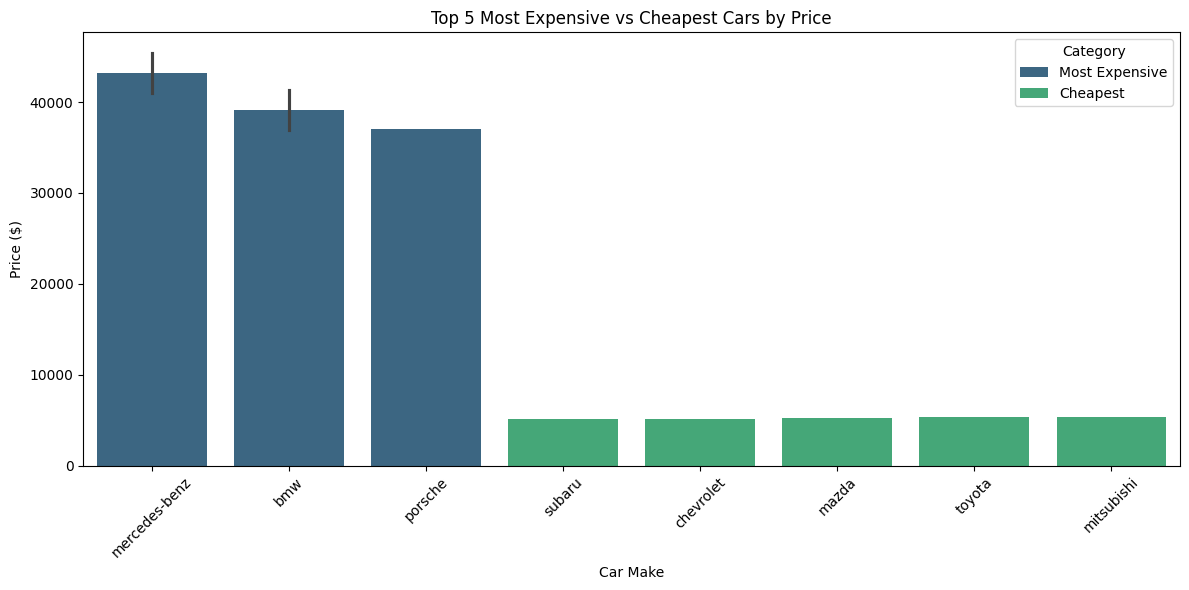

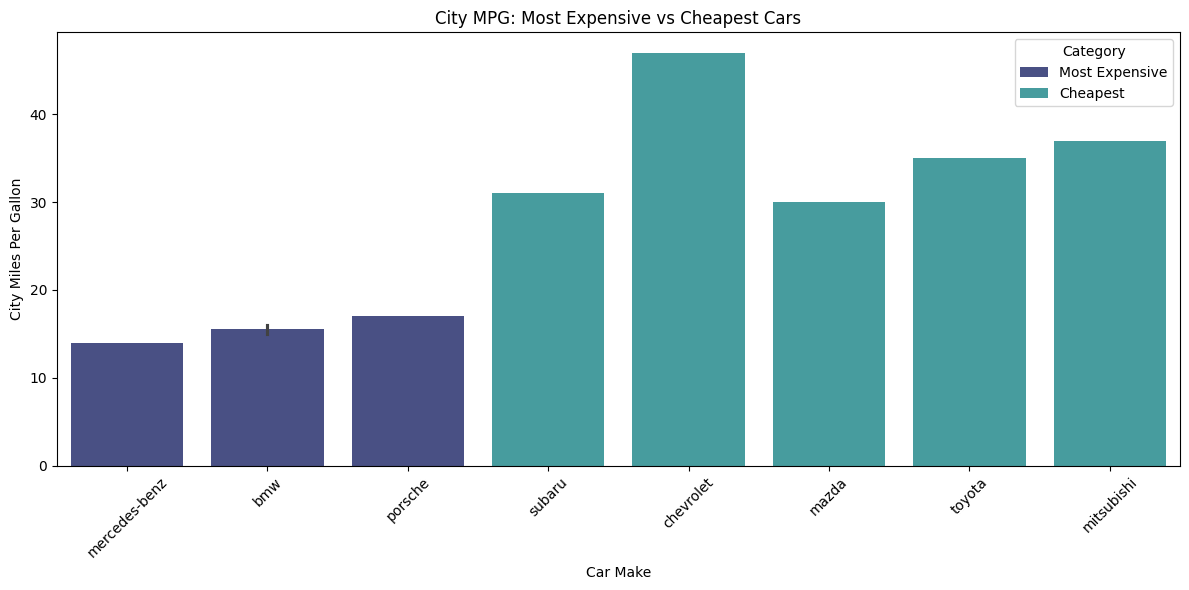

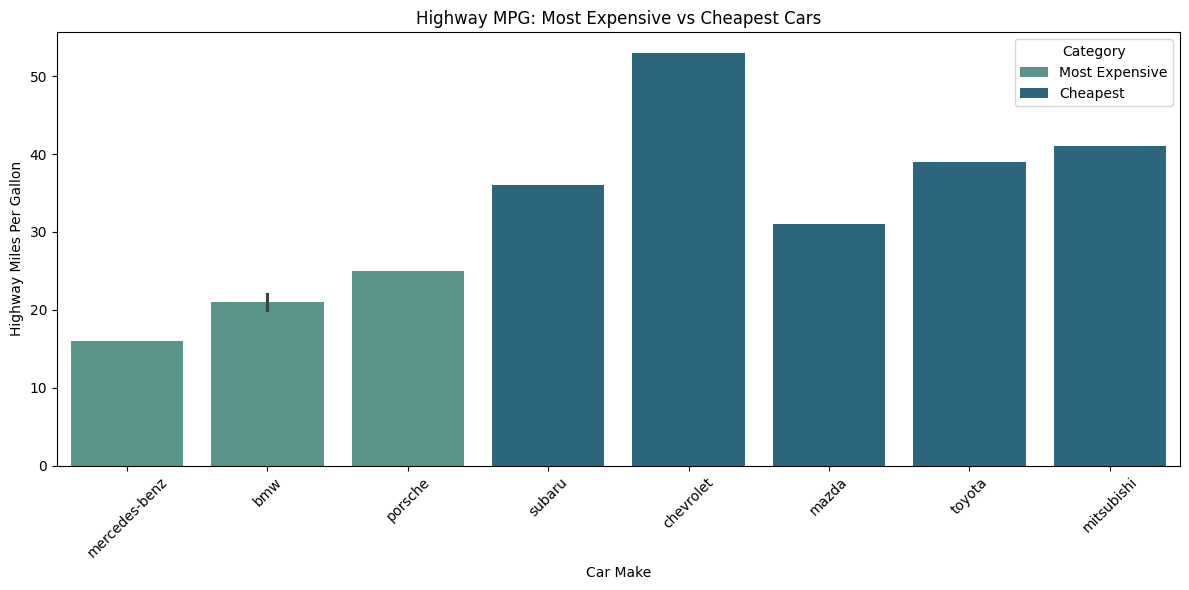

In [8]:
# Identify top 5 most expensive and 5 cheapest cars
top_5 = temp_df.sort_values(by='price', ascending=False).head(5)
bottom_5 = temp_df.sort_values(by='price', ascending=True).head(5)

# Combine for comparison
comparison = pd.concat([
    top_5.assign(Category='Most Expensive'),
    bottom_5.assign(Category='Cheapest')
])

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparison,
    x='make',
    y='price',
    hue='Category',
    palette='viridis'
)
plt.title('Top 5 Most Expensive vs Cheapest Cars by Price')
plt.xlabel('Car Make')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Fuel economy comparison (City vs Highway)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparison,
    x='make',
    y='city-mpg',
    hue='Category',
    palette='mako'
)
plt.title('City MPG: Most Expensive vs Cheapest Cars')
plt.xlabel('Car Make')
plt.ylabel('City Miles Per Gallon')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparison,
    x='make',
    y='highway-mpg',
    hue='Category',
    palette='crest'
)
plt.title('Highway MPG: Most Expensive vs Cheapest Cars')
plt.xlabel('Car Make')
plt.ylabel('Highway Miles Per Gallon')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

C:\Users\Mkoka\AppData\Local\Temp\ipykernel_23228\4217966023.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


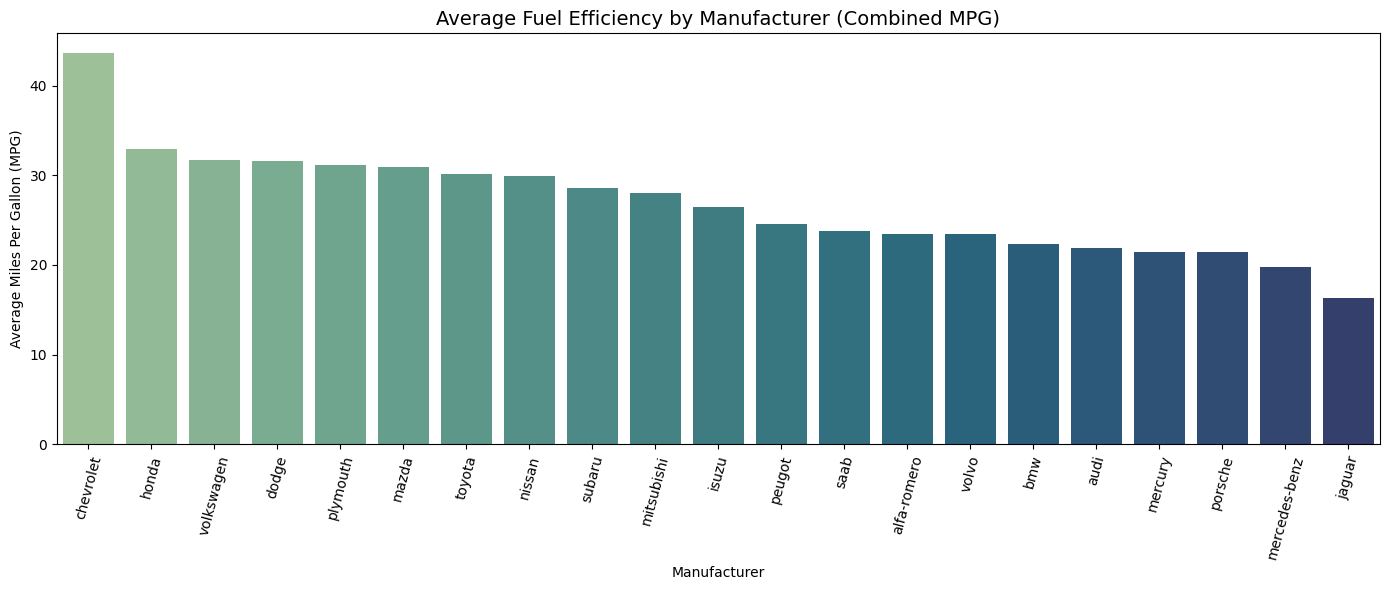

<Figure size 1400x600 with 0 Axes>

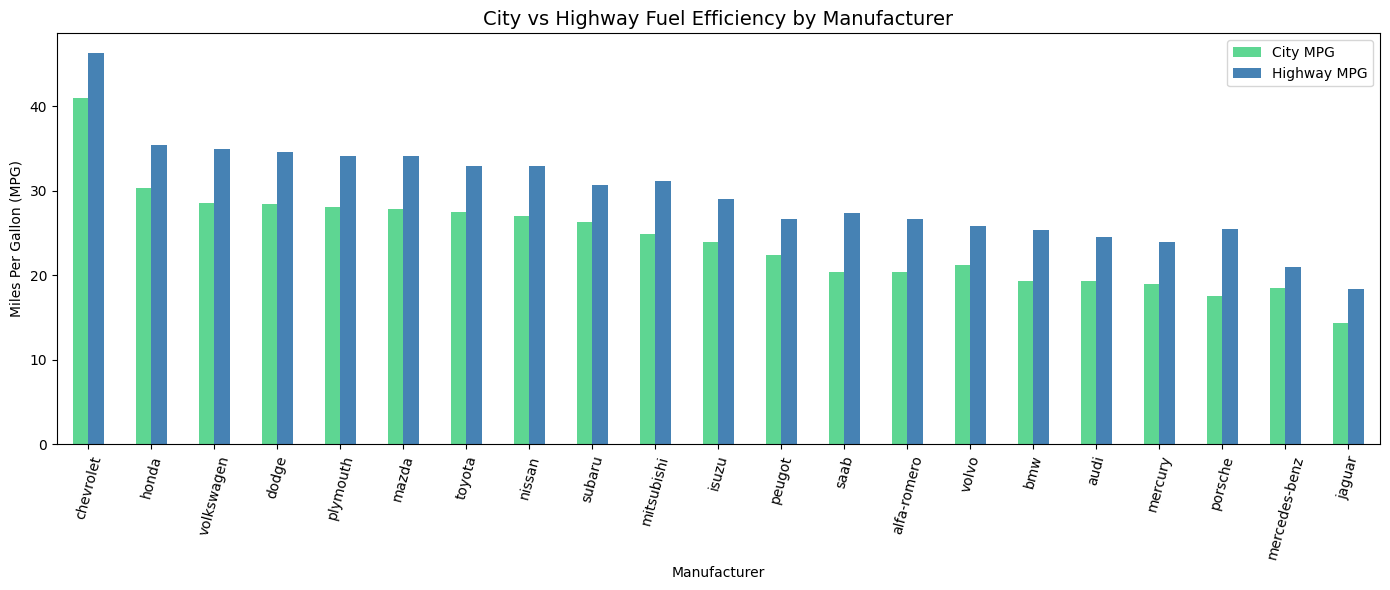

In [9]:
# Calculate average city, highway, and overall mpg by manufacturer
mpg_stats = temp_df.groupby('make')[['city-mpg', 'highway-mpg']].mean()
mpg_stats['avg-mpg'] = (mpg_stats['city-mpg'] + mpg_stats['highway-mpg']) / 2
mpg_stats = mpg_stats.sort_values(by='avg-mpg', ascending=False)

# Visualization 1: Average MPG (combined)
plt.figure(figsize=(14, 6))
sns.barplot(
    x=mpg_stats.index,
    y=mpg_stats['avg-mpg'],
    palette='crest'
)
plt.title('Average Fuel Efficiency by Manufacturer (Combined MPG)', fontsize=14)
plt.xlabel('Manufacturer')
plt.ylabel('Average Miles Per Gallon (MPG)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# Visualization 2: City vs Highway MPG comparison ---
plt.figure(figsize=(14, 6))
mpg_stats[['city-mpg', 'highway-mpg']].plot(
    kind='bar',
    figsize=(14, 6),
    color=["#5ED692", '#4682B4']
)
plt.title('City vs Highway Fuel Efficiency by Manufacturer', fontsize=14)
plt.xlabel('Manufacturer')
plt.ylabel('Miles Per Gallon (MPG)')
plt.xticks(rotation=75)
plt.legend(['City MPG', 'Highway MPG'])
plt.tight_layout()
plt.show()

#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

In [10]:
# Create a copy of the dataset and sort based on the engine size
df_sorted = temp_df.sort_values(by='engine-size', ascending=False)

# Display sorted results
print(df_sorted.head())

             make fuel-type aspiration num-of-doors body-style drive-wheels  \
49         jaguar       gas        std          two      sedan          rwd   
73  mercedes-benz       gas        std         four      sedan          rwd   
74  mercedes-benz       gas        std          two    hardtop          rwd   
47         jaguar       gas        std         four      sedan          rwd   
48         jaguar       gas        std         four      sedan          rwd   

   engine-location  wheel-base  length  width  ...  engine-size  fuel-system  \
49           front         102     191     70  ...          326         mpfi   
73           front         120     208     71  ...          308         mpfi   
74           front         112     199     72  ...          304         mpfi   
47           front         113     199     69  ...          258         mpfi   
48           front         113     199     69  ...          258         mpfi   

    bore stroke  compression-ratio horsepowe

#### Which vehicle manufacturer has the most car models in the dataset

In [11]:
# Count the number of models per manufacturer using the 'make' column
manufacturer_counts = temp_df['make'].value_counts()

# Get the manufacturer with the most models
top_manufacturer = manufacturer_counts.idxmax()
top_model_count = manufacturer_counts.max()

# Print the result for the manufacturer with the most models
print(f"The manufacturer with the most car models is {top_manufacturer} with {top_model_count} models.\n")
print("Top 5 manufacturers by number of models:")
print(manufacturer_counts.head(5))
print("\n")

# Task 2: Sort the dataframe by engine-size in descending order
# Convert 'engine-size' to numeric (in case it's read as a string)
temp_df['engine-size'] = pd.to_numeric(temp_df['engine-size'], errors='coerce')

# Sort the dataframe by 'engine-size' in descending order
df_sorted = temp_df.sort_values(by='engine-size', ascending=False)

# Select relevant columns for display
columns_to_display = ['make', 'engine-size', 'body-style', 'fuel-type', 'price']

# Print the top 5 vehicles with the largest engine sizes
print("Top 5 vehicles with the largest engine sizes:")
print(df_sorted[columns_to_display].head(5))

The manufacturer with the most car models is toyota with 32 models.

Top 5 manufacturers by number of models:
make
toyota        32
nissan        18
mitsubishi    13
honda         13
subaru        12
Name: count, dtype: int64


Top 5 vehicles with the largest engine sizes:
             make  engine-size body-style fuel-type  price
49         jaguar          326      sedan       gas  36000
73  mercedes-benz          308      sedan       gas  40960
74  mercedes-benz          304    hardtop       gas  45400
47         jaguar          258      sedan       gas  32250
48         jaguar          258      sedan       gas  35550
